# Archived: 2.3 Joint Composite-Cost Equilibrium

Notebook 2.0 solves the three EIP-7999 fees in sequence: execution and state clear their own
targets, the resulting activity generates runtime BAL, and the data fee then clears whatever
target is left. The data price never feeds back into execution or state demand, even though the
transactions that generate BAL are the ones paying for it.

This notebook closes that loop. Each activity is priced at the **full cost it pays**, so a higher
data fee directly reduces the execution and state activity that produces BAL, and all three fees
are solved simultaneously.

Two structural changes are required for the accounting to add up, and both are calibrated here
rather than assumed:

1. **Activities are partitioned by transaction type**, so execution gas carried by state-creating
   transactions is not counted twice.
2. **Each activity's reference price is its historical composite cost**, not the common anchor
   $p^0$ &mdash; otherwise a state creator appears to suffer a threefold cost increase that is pure
   accounting artifact.

Notebook 2.0 is unchanged and remains the no-feedback benchmark.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from itertools import combinations

from scipy.optimize import root

plt.rcParams.update({
    "font.size": 14, "axes.titlesize": 16, "axes.labelsize": 14,
    "xtick.labelsize": 14, "ytick.labelsize": 14,
    "legend.fontsize": 14, "figure.titlesize": 18,
})
plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.6f}".format

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)
DATE_LABEL = "2026-02-01_2026-06-01"
GWEI = 1e9
MIN_FEE_WEI = 1.0
CENTRAL_WINDOW = 35
RESOURCES = ("execution", "data", "state")

CARD_CSV = DATA_DIR / f"full_7999_equilibrium_accounting_card_{DATE_LABEL}.csv"
HEADLINE_CSV = DATA_DIR / f"full_7999_equilibrium_headline_{DATE_LABEL}.csv"
ELASTICITY_CSV = DATA_DIR / "three_way_isoelastic_calibration_2025.csv"
CARRIER_PANEL = DATA_DIR / f"calibration_xatu_bal_runtime_8279_carrier_panel_{DATE_LABEL}.parquet"
OUT_PAIRED_CSV = DATA_DIR / f"joint_composite_paired_{DATE_LABEL}.csv"
OUT_FRONTIER_CSV = DATA_DIR / f"joint_composite_frontier_{DATE_LABEL}.csv"
OUT_PLOT = PLOTS_DIR / f"joint_composite_equilibrium_{DATE_LABEL}.png"

card = pd.read_csv(CARD_CSV).iloc[0]
headline = pd.read_csv(HEADLINE_CSV).sort_values("data_gas_target").reset_index(drop=True)
elasticities = pd.read_csv(ELASTICITY_CSV).sort_values("window_days")
WINDOW_DAYS = elasticities["window_days"].astype(int).tolist()
EPS_BY_WINDOW = {
    int(r.window_days): {
        "execution": float(r.eps_execution),
        "data": float(r.eps_data),
        "state": float(r.eps_state),
    }
    for r in elasticities.itertuples(index=False)
}
EPS = EPS_BY_WINDOW[CENTRAL_WINDOW]
EPS

{'execution': 0.1211596378167212,
 'data': 0.2294762749968381,
 'state': 0.3348638470580466}

## Partition activities by transaction type

The joint model needs each unit of activity to pay for everything it consumes, without any
resource being charged twice. A state-creating transaction consumes state gas, a substantial
amount of execution gas, and generates BAL. If `x_execution` were *total* execution activity while
the state price also charged for execution, that execution gas would be priced twice but counted
once, and the system would not add up.

The activities are therefore defined by transaction type:

- $x_S$ &mdash; state-creating activity
- $x_E$ &mdash; execution activity of transactions that do **not** create state
- $x_C$ &mdash; static transaction content

Splitting BAL the same way has a useful consequence. BAL produced by state-creating transactions
is $d + c$ and BAL produced by every other transaction is $n$, so the transaction-type partition
reproduces the $\lambda=1$ weights exactly. The allocation parameter $\lambda$ is not a free
choice in this model: a transaction pays for all of the BAL it generates, whether that BAL comes
from its own state diffs or from the accesses that accompany them.

In [2]:
p0 = float(card["historical_base_fee_ref_gwei"])
m_execution = float(card["execution_metering_multiplier"])
m_state = float(card["state_metering_multiplier"])
m_data = float(card["data_metering_multiplier_no_bal"])
anchor_gas = {
    "execution": float(card["execution_7999_gas_per_block"]),
    "state": float(card["state_7999_gas_per_block"]),
    "data": float(card["data_7999_gas_with_bal_per_block"]),
}
bal_anchor_gas = float(card["bal_7999_gas_per_block"])
d_share = float(card["bal_direct_state_weight"])
c_share = float(card["bal_coproduced_state_transaction_weight"])
n_share = float(card["bal_nonstate_transaction_weight"])

panel = pd.read_parquet(CARRIER_PANEL)
panel_blocks = panel["block_number"].nunique()
is_creator = panel["state_metered_gas_8037"] > 0

# Non-carrier transactions create no state, so they belong entirely to the non-state group.
carrier_execution_share = (
    panel["execution_metered_gas_7999"].sum() / panel_blocks / anchor_gas["execution"]
)
creator_share_of_carrier_execution = (
    panel.loc[is_creator, "execution_metered_gas_7999"].sum()
    / panel["execution_metered_gas_7999"].sum()
)
creator_execution_gas = (
    anchor_gas["execution"] * carrier_execution_share * creator_share_of_carrier_execution
)

# BAL by transaction type is exactly the (d + c) / n split.
observed_creator_bal_share = (
    panel.loc[is_creator, "bal_metered_gas_7999"].sum() / panel["bal_metered_gas_7999"].sum()
)
if not np.isclose(observed_creator_bal_share, d_share + c_share, atol=1e-6):
    raise AssertionError("transaction-type BAL split must equal the d + c decomposition")

x_state = float(card["state_historical_quantity_per_block"])
x_execution = (anchor_gas["execution"] - creator_execution_gas) / m_execution
x_content = float(card["data_historical_quantity_per_block"])

a_execution_state = creator_execution_gas / x_state          # 7999 execution gas per state unit
a_bal_state = bal_anchor_gas * (d_share + c_share) / x_state  # BAL gas per state unit
a_bal_execution = bal_anchor_gas * n_share / x_execution      # BAL gas per execution unit
historical_execution_per_state = a_execution_state / m_execution

display(pd.DataFrame({
    "value": {
        "x_execution (historical, non-state)": x_execution,
        "x_state (historical)": x_state,
        "x_content (historical)": x_content,
        "a_execution_state": a_execution_state,
        "a_bal_state": a_bal_state,
        "a_bal_execution": a_bal_execution,
        "state creators' share of execution gas": creator_execution_gas / anchor_gas["execution"],
        "BAL share from state creators": observed_creator_bal_share,
    }
}))

,value
"x_execution (historical, non-state)","13,674,325.759824"
x_state (historical),"5,244,154.703798"
x_content (historical),"1,180,555.063055"
a_execution_state,3.011163
a_bal_state,0.180314
a_bal_execution,0.071192
state creators' share of execution gas,0.428862
BAL share from state creators,0.492728


## Composite activity prices

Each activity pays for every resource it consumes:

$$
P_E = m_E b_E + a_{DE}\,b_D,
\qquad
P_S = m_S b_S + a_{ES}\,b_E + a_{DS}\,b_D,
\qquad
P_C = m_D b_D .
$$

The reference price must be the **historical composite** &mdash; everything the activity already
paid, at the historical shared price. Execution and static content each paid $p^0$ per historical
unit. State-creating activity also carried execution gas, so its historical cost per unit was
$p^0\left(1 + a_{ES}/m_E\right)$.

Getting this wrong is not a rounding matter. Using $p^0$ for state would make the composite price
at the anchor fees look roughly three times its reference, and the model would report state
activity collapsing on contact for purely notational reasons. With the historical composite the
only change at the anchor fees is the genuinely new BAL charge.

In [3]:
reference_fees = {
    "execution": p0 / m_execution,
    "data": p0 / m_data,
    "state": p0 / m_state,
}
composite_reference = {
    "execution": p0,
    "state": p0 * (1.0 + historical_execution_per_state),
    "content": p0,
}

def composite_prices(fees, *, coupled=True):
    # Composite activity prices in gwei, from the three protocol base fees in gwei.
    # coupled=False drops the data price from the execution and state composites, which
    # isolates the feedback this notebook adds from the effect of the partition itself.
    bal_fee = fees["data"] if coupled else 0.0
    return {
        "execution": m_execution * fees["execution"] + a_bal_execution * bal_fee,
        "state": (
            m_state * fees["state"]
            + a_execution_state * fees["execution"]
            + a_bal_state * bal_fee
        ),
        "content": m_data * fees["data"],
    }

anchor_composite = composite_prices(reference_fees)
anchor_table = pd.DataFrame({
    "historical composite (gwei)": composite_reference,
    "EIP-7999 composite at anchors (gwei)": anchor_composite,
})
anchor_table["ratio"] = (
    anchor_table["EIP-7999 composite at anchors (gwei)"]
    / anchor_table["historical composite (gwei)"]
)
anchor_table["new BAL charge, share of cost"] = pd.Series({
    "execution": a_bal_execution * reference_fees["data"] / anchor_composite["execution"],
    "state": a_bal_state * reference_fees["data"] / anchor_composite["state"],
    "content": 0.0,
})
display(anchor_table)

,historical composite (gwei),EIP-7999 composite at anchors (gwei),ratio,"new BAL charge, share of cost"
execution,0.106928,0.111140,1.039393,0.037900
state,0.316290,0.326958,1.033730,0.032629
content,0.106928,0.106928,1.000000,0.000000


## The joint system

With isoelastic activity demand,

$$
x_i = x_i^0\left(\frac{P_i}{P_i^0}\right)^{-\epsilon_i},
$$

resource usage aggregates the activities that consume each resource:

$$
G_E = m_E x_E + a_{ES} x_S,
\qquad
G_S = m_S x_S,
\qquad
G_D = m_D x_C + a_{DE} x_E + a_{DS} x_S .
$$

The equilibrium solves $G_E = T_E$, $G_S = T_S$, and $G_D = T_D$ simultaneously for
$(b_E, b_S, b_D)$. Because the protocol cannot charge below one wei, the solve is a
complementarity problem: each resource either clears its target at a fee above the minimum, or
sits at one wei with usage below target.

The `coupled` switch removes the data price from $P_E$ and $P_S$, which isolates the feedback this
notebook adds from the effect of the partition itself.

In [4]:
def activity_levels(fees, eps, *, coupled=True):
    prices = composite_prices(fees, coupled=coupled)
    return {
        "execution": x_execution * (prices["execution"] / composite_reference["execution"])
        ** (-eps["execution"]),
        "state": x_state * (prices["state"] / composite_reference["state"]) ** (-eps["state"]),
        "content": x_content * (prices["content"] / composite_reference["content"])
        ** (-eps["data"]),
    }

def resource_usage(fees, eps, *, coupled=True):
    x = activity_levels(fees, eps, coupled=coupled)
    return {
        "execution": m_execution * x["execution"] + a_execution_state * x["state"],
        "state": m_state * x["state"],
        "data": (
            m_data * x["content"]
            + a_bal_execution * x["execution"]
            + a_bal_state * x["state"]
        ),
    }

def _solve_with_pins(targets, eps, pinned, *, coupled=True):
    free = [r for r in RESOURCES if r not in pinned]

    def unpack(log_fees):
        out = {r: MIN_FEE_WEI / GWEI for r in RESOURCES}
        for resource, value in zip(free, np.exp(np.clip(log_fees, -80.0, 20.0))):
            out[resource] = value
        return out

    if not free:
        fees = unpack([])
        return fees, resource_usage(fees, eps, coupled=coupled), True

    def residual(log_fees):
        usage = resource_usage(unpack(log_fees), eps, coupled=coupled)
        return [np.log(max(usage[r], 1e-12) / targets[r]) for r in free]

    # A single starting guess fails sporadically at extreme target combinations, so try
    # several decades around the anchor and keep the first that converges.
    for scale in (1.0, 1e-2, 1e-4, 1e-7, 1e-11, 1e2):
        solution = root(
            residual,
            [np.log(reference_fees[r] * scale) for r in free],
            method="hybr",
            tol=1e-13,
        )
        if bool(solution.success) and float(np.max(np.abs(residual(solution.x)))) < 1e-8:
            fees = unpack(solution.x)
            return fees, resource_usage(fees, eps, coupled=coupled), True
    fees = unpack(solution.x)
    return fees, resource_usage(fees, eps, coupled=coupled), False

def solve_joint(targets, eps, *, coupled=True):
    # Complementarity: every resource either clears its target at a fee above the protocol
    # minimum, or sits at one wei with usage strictly below target.  Enumerate the eight
    # pin sets and keep the first assignment satisfying both conditions -- pinning greedily
    # without checking that a pinned resource is under target admits false solutions where,
    # for example, state is held at one wei while its usage runs at twice the target.
    chosen = None
    for pin_count in range(len(RESOURCES) + 1):
        for pinned in combinations(RESOURCES, pin_count):
            fees, usage, converged = _solve_with_pins(
                targets, eps, set(pinned), coupled=coupled
            )
            if not converged:
                continue
            free_above_minimum = all(
                fees[r] * GWEI >= MIN_FEE_WEI * (1 - 1e-9)
                for r in RESOURCES
                if r not in pinned
            )
            pinned_below_target = all(
                usage[r] <= targets[r] * (1 + 1e-9) for r in pinned
            )
            if free_above_minimum and pinned_below_target:
                chosen = (fees, usage, pinned)
                break
        if chosen is not None:
            break
    if chosen is None:
        return {
            **{f"{r}_fee_wei": np.nan for r in RESOURCES},
            **{f"{r}_gas": np.nan for r in RESOURCES},
            **{f"{r}_share_of_target": np.nan for r in RESOURCES},
            "pinned_at_minimum": "", "all_targets_reached": False, "solved": False,
        }
    fees, usage, pinned = chosen
    return {
        **{f"{r}_fee_wei": fees[r] * GWEI for r in RESOURCES},
        **{f"{r}_gas": usage[r] for r in RESOURCES},
        **{f"{r}_share_of_target": usage[r] / targets[r] for r in RESOURCES},
        "pinned_at_minimum": ",".join(sorted(pinned)),
        "all_targets_reached": all(
            usage[r] >= targets[r] * (1 - 1e-9) for r in RESOURCES
        ),
        "solved": True,
    }

# The partition is an accounting identity at the historical activity levels: it must
# rebuild the notebook 2.0 anchors exactly.
partition_identity = {
    "execution": m_execution * x_execution + a_execution_state * x_state,
    "state": m_state * x_state,
    "data": (
        m_data * x_content + a_bal_execution * x_execution + a_bal_state * x_state
    ),
}
check = pd.DataFrame({
    "partition identity": partition_identity,
    "accounting card": anchor_gas,
})
check["relative error"] = (check["partition identity"] / check["accounting card"] - 1).abs()
if check["relative error"].max() > 5e-9:
    raise AssertionError("the partition must reproduce the notebook 2.0 anchors exactly")

# Evaluated at the per-resource anchor fees the demand curves sit slightly below this, because
# the new BAL charge is a real cost increase that did not exist historically.
anchor_usage = resource_usage(reference_fees, EPS)
check["usage at anchor fees"] = pd.Series(anchor_usage)
check["reduction from new BAL charge"] = (
    check["usage at anchor fees"] / check["partition identity"] - 1
)
display(check)

,partition identity,accounting card,relative error,usage at anchor fees,reduction from new BAL charge
execution,"36,820,725.629258","36,820,725.629258",0.000000,"36,548,065.673935",-0.007405
state,"29,662,592.274090","29,662,592.274090",0.000000,"29,334,904.254356",-0.011047
data,"4,052,658.698145","4,052,658.698145",0.000000,"4,037,666.042359",-0.003699


## Benchmark check: switching the feedback off

With the data price removed from the execution and state composites, the only difference from
notebook 2.0 is the partition. The data fees below should sit close to 2.0's, while the execution
fee differs more, and not in one direction. Near the anchor, splitting execution between two
activities makes the execution resource *more* responsive to its own price than a single curve at
$\epsilon_{\mathrm{execution}}$. Far above the anchor the opposite holds: the execution gas
carried by state creators is fixed once state clears its own target, so the non-state activity has
to stretch further than a single pooled curve would, from a smaller base.

In [5]:
def scenario_targets(row):
    return {
        "execution": float(row.execution_gas_limit) / 2.0,
        "data": float(row.data_gas_target),
        "state": float(row.state_gas_target),
    }

rows = []
for row in headline.itertuples(index=False):
    targets = scenario_targets(row)
    for coupled, label in [(False, "feedback off"), (True, "feedback on")]:
        solved = solve_joint(targets, EPS, coupled=coupled)
        rows.append({
            "scenario": row.scenario,
            "execution_target": targets["execution"],
            "data_target": targets["data"],
            "specification": label,
            "notebook_2_0_execution_fee_wei": float(row.execution_protocol_base_fee_wei),
            "notebook_2_0_data_fee_wei": float(row.data_protocol_base_fee_wei),
            **solved,
        })
paired = pd.DataFrame(rows)
paired.to_csv(OUT_PAIRED_CSV, index=False)

benchmark = paired[paired["specification"].eq("feedback off")]
display(benchmark[[
    "scenario", "execution_fee_wei", "notebook_2_0_execution_fee_wei",
    "data_fee_wei", "notebook_2_0_data_fee_wei", "state_fee_wei", "all_targets_reached",
]])
sensitivity_slope = (
    np.log(resource_usage({**reference_fees, "execution": reference_fees["execution"] * 1.000001}, EPS)["execution"])
    - np.log(anchor_usage["execution"])
) / 1e-6
print(f"effective execution elasticity at the anchor: {abs(sensitivity_slope):.4f}")
print(f"notebook 2.0 uses a single curve at        : {EPS['execution']:.4f}")

,scenario,execution_fee_wei,notebook_2_0_execution_fee_wei,data_fee_wei,notebook_2_0_data_fee_wei,state_fee_wei,all_targets_reached
0,matched_E272.6_D90_T1of6_S75,243.298304,"1,417.000000","172,172.057500","171,734.000000","3,503,504.712672",True
2,matched_E327.1_D90_T1of5_S75,31.134335,315.000000,"74,134.923119","73,882.000000","3,503,617.659063",True
4,matched_E408.9_D90_T1of4_S75,2.944448,50.000000,"26,733.358255","26,619.000000","3,503,632.666069",True
6,matched_E545.1_D90_T1of3_S75,1.000000,5.000000,"4,372.788095","7,243.000000","3,503,633.701204",False


effective execution elasticity at the anchor: 0.1584
notebook 2.0 uses a single curve at        : 0.1212


## Equilibrium with the feedback on

Switching the data price into the execution and state composites changes the result
qualitatively. The execution fee falls to the one-wei minimum in every paired scenario and
execution still does not reach its target, because at a one-wei execution fee almost the entire
cost of execution activity is the BAL data charge, which the execution fee cannot offset.

In [6]:
comparison = paired.pivot_table(
    index="scenario", columns="specification",
    values=["execution_fee_wei", "data_fee_wei", "execution_share_of_target"],
)
display(paired[paired["specification"].eq("feedback on")][[
    "scenario", "execution_fee_wei", "data_fee_wei", "state_fee_wei",
    "execution_gas", "execution_share_of_target", "pinned_at_minimum",
]])

worst = paired[paired["specification"].eq("feedback on")]
for row in worst.itertuples(index=False):
    fees = {
        "execution": row.execution_fee_wei / GWEI,
        "data": row.data_fee_wei / GWEI,
        "state": row.state_fee_wei / GWEI,
    }
    prices = composite_prices(fees)
    bal_share = a_bal_execution * fees["data"] / prices["execution"]
    print(
        f"{row.scenario:<30} BAL is {bal_share * 100:5.2f}% of the composite execution price"
    )

,scenario,execution_fee_wei,data_fee_wei,state_fee_wei,execution_gas,execution_share_of_target,pinned_at_minimum
1,matched_E272.6_D90_T1of6_S75,1.000000,"90,317.917118","3,500,754.515984","108,195,277.977200",0.793898,execution
3,matched_E327.1_D90_T1of5_S75,1.000000,"31,634.871577","3,502,625.234030","117,444,047.175448",0.718135,execution
5,matched_E408.9_D90_T1of4_S75,1.000000,"9,237.764654","3,503,339.216607","129,893,829.161785",0.635409,execution
7,matched_E545.1_D90_T1of3_S75,1.000000,"2,017.565312","3,503,569.384572","147,995,768.721086",0.542970,execution


matched_E272.6_D90_T1of6_S75   BAL is 99.98% of the composite execution price
matched_E327.1_D90_T1of5_S75   BAL is 99.93% of the composite execution price
matched_E408.9_D90_T1of4_S75   BAL is 99.77% of the composite execution price
matched_E545.1_D90_T1of3_S75   BAL is 98.94% of the composite execution price


## The feasible capacity frontier

The useful form of this result is not that the ratio-matched scenarios fail, but what capacity
pairing would work. Raising the data target lowers the data fee, which lowers the BAL charge
carried by execution activity, which lets execution reach a higher target. For each execution
target the frontier reports the smallest data target at which execution still clears.

In [7]:
def execution_clears(data_target, execution_target, eps):
    targets = {"execution": execution_target, "data": data_target, "state": 75_000_000.0}
    solved = solve_joint(targets, eps, coupled=True)
    return bool(solved["solved"]) and solved["execution_share_of_target"] >= 1.0 - 1e-9

def minimum_data_target(execution_target, eps, low=5e6, high=600e6, tol=2.5e4):
    # "execution clears" is monotone in the data target: a larger data target lowers the data
    # fee, which lowers the BAL charge carried by execution activity.  Bisect the predicate,
    # because the slack itself is exactly zero everywhere above the threshold.
    if not execution_clears(high, execution_target, eps):
        return np.nan
    if execution_clears(low, execution_target, eps):
        return low
    while high - low > tol:
        middle = 0.5 * (low + high)
        if execution_clears(middle, execution_target, eps):
            high = middle
        else:
            low = middle
    return high

DATA_GAS_LIMIT = 90_000_000.0
LARGEST_STUDIED_DATA_TARGET = 45_000_000.0

def largest_execution_target(data_target_cap, eps, low=80e6, high=320e6, tol=2.5e5):
    # Largest execution target whose required data target still fits under a cap.
    fits = lambda target: (
        not np.isnan(m := minimum_data_target(target, eps)) and m <= data_target_cap
    )
    if not fits(low):
        return np.nan
    if fits(high):
        return high
    while high - low > tol:
        middle = 0.5 * (low + high)
        if fits(middle):
            low = middle
        else:
            high = middle
    return low

caps = pd.DataFrame([
    {
        "window_days": window,
        "largest execution target with T_data <= 45M (studied range)":
            largest_execution_target(LARGEST_STUDIED_DATA_TARGET, EPS_BY_WINDOW[window]),
        "largest execution target with T_data <= 90M (data gas limit)":
            largest_execution_target(DATA_GAS_LIMIT, EPS_BY_WINDOW[window]),
    }
    for window in WINDOW_DAYS
]).set_index("window_days")
display(caps / 1e6)

frontier_rows = []
for execution_target in np.arange(100e6, 305e6, 12.5e6):
    for window in WINDOW_DAYS:
        frontier_rows.append({
            "window_days": window,
            "execution_target": execution_target,
            "ratio_matched_data_target": execution_target * 0.110065,
            "minimum_data_target": minimum_data_target(
                execution_target, EPS_BY_WINDOW[window]
            ),
        })
frontier = pd.DataFrame(frontier_rows)
frontier["multiple_of_ratio_match"] = (
    frontier["minimum_data_target"] / frontier["ratio_matched_data_target"]
)
frontier.to_csv(OUT_FRONTIER_CSV, index=False)
display(
    frontier[frontier["window_days"].eq(CENTRAL_WINDOW)][
        ["execution_target", "ratio_matched_data_target", "minimum_data_target",
         "multiple_of_ratio_match"]
    ]
)

,largest execution target with T_data <= 45M (studied range),largest execution target with T_data <= 90M (data gas limit)
window_days,,
21,190.625000,213.125000
35,177.265625,219.921875
60,124.062500,131.328125
75,120.546875,126.406250


,execution_target,ratio_matched_data_target,minimum_data_target,multiple_of_ratio_match
1,"100,000,000.000000","11,006,500.000000","12,590,026.855469",1.143872
5,"112,500,000.000000","12,382,312.500000","16,366,882.324219",1.321795
9,"125,000,000.000000","13,758,125.000000","20,670,318.603516",1.502408
13,"137,500,000.000000","15,133,937.500000","25,518,493.652344",1.686177
17,"150,000,000.000000","16,509,750.000000","30,911,407.470703",1.872312
21,"162,500,000.000000","17,885,562.500000","36,903,533.935547",2.063314
25,"175,000,000.000000","19,261,375.000000","43,603,820.800781",2.263796
29,"187,500,000.000000","20,637,187.500000","51,339,111.328125",2.487699
33,"200,000,000.000000","22,013,000.000000","60,835,723.876953",2.763627
37,"212,500,000.000000","23,388,812.500000","74,672,088.623047",3.192641


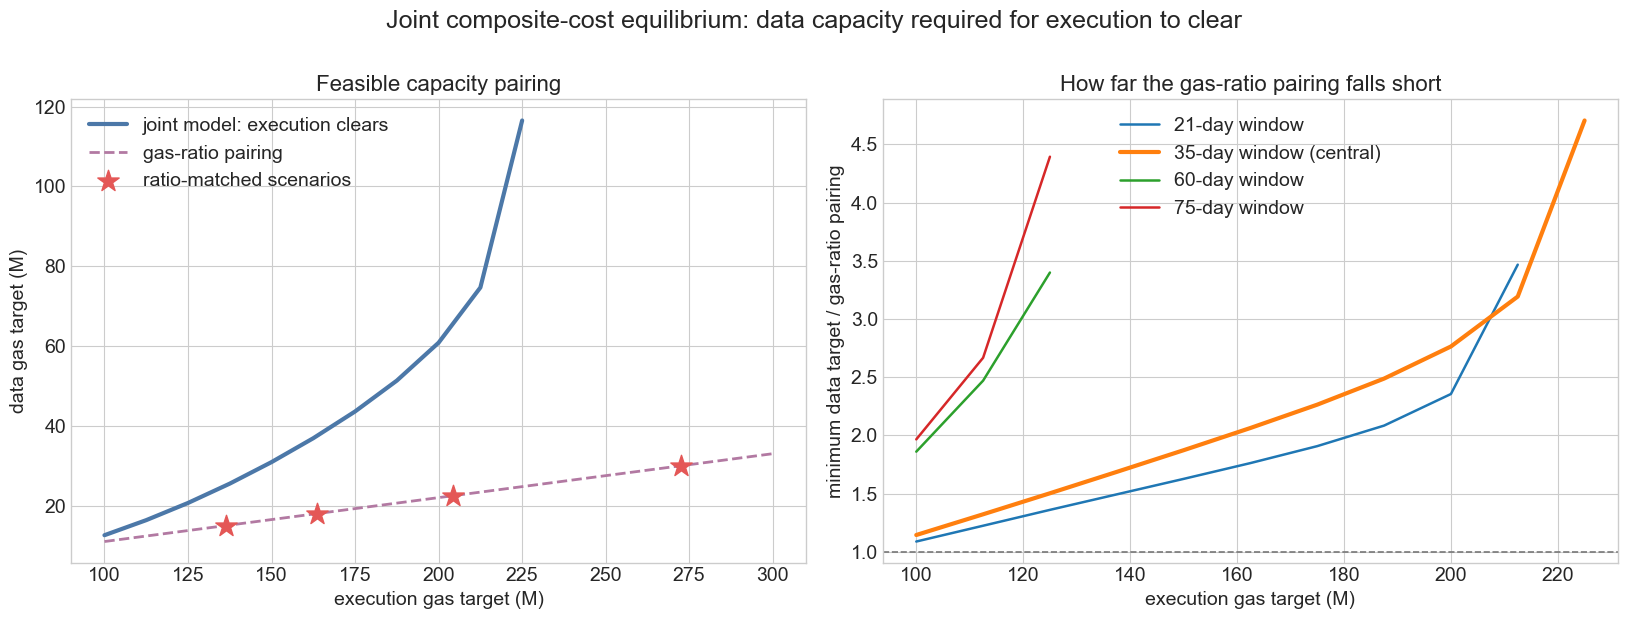

In [8]:
central = frontier[frontier["window_days"].eq(CENTRAL_WINDOW)]
fig, axes = plt.subplots(1, 2, figsize=(16.5, 6.2))

ax = axes[0]
ax.plot(central["execution_target"] / 1e6, central["minimum_data_target"] / 1e6,
        color="#4C78A8", linewidth=3.0, label="joint model: execution clears")
ax.plot(central["execution_target"] / 1e6, central["ratio_matched_data_target"] / 1e6,
        color="#B279A2", linewidth=2.0, linestyle="--", label="gas-ratio pairing")
paired_on = paired[paired["specification"].eq("feedback on")]
ax.scatter(paired_on["execution_target"] / 1e6, paired_on["data_target"] / 1e6,
           marker="*", s=260, color="#E45756", zorder=5, label="ratio-matched scenarios")
ax.set_xlabel("execution gas target (M)")
ax.set_ylabel("data gas target (M)")
ax.set_title("Feasible capacity pairing")
ax.legend(frameon=False)

ax = axes[1]
for window in WINDOW_DAYS:
    sub = frontier[frontier["window_days"].eq(window)]
    is_central = window == CENTRAL_WINDOW
    ax.plot(sub["execution_target"] / 1e6, sub["multiple_of_ratio_match"],
            linewidth=3.0 if is_central else 1.8,
            label=f"{window}-day window" + (" (central)" if is_central else ""))
ax.axhline(1.0, color="#777777", linestyle="--", linewidth=1.2)
ax.set_xlabel("execution gas target (M)")
ax.set_ylabel("minimum data target / gas-ratio pairing")
ax.set_title("How far the gas-ratio pairing falls short")
ax.legend(frameon=False)

fig.suptitle("Joint composite-cost equilibrium: data capacity required for execution to clear", y=1.0)
fig.tight_layout()
fig.savefig(OUT_PLOT, dpi=180, bbox_inches="tight")
plt.show()

## What this changes, and what it does not settle

**The feedback is decisive, not marginal.** In the sequential model all four ratio-matched
scenarios clear every target. Once execution and state pay for the BAL they generate, the
execution fee falls to the one-wei minimum in all four and execution still lands at only
**54--79%** of target. The mechanism is visible in one number: at a one-wei execution fee,
**98.9--99.98%** of what execution activity pays is the data charge on its BAL. Lowering the
execution fee cannot offset a cost the execution fee does not control.

**Pairing capacity by gas ratio is not sufficient.** The ratio-matched scenarios equalise the
*quantity* ratio while leaving the data fee orders of magnitude above the execution fee, and the
same transactions pay both. The frontier gives the pairing that works: the data target must be
**1.14x** the gas-ratio pairing at a 100M execution target, rising to **3.19x** at 212.5M. Beyond
roughly **225M** no data target clears execution at all.

**The elasticity window matters more here than in notebook 2.0.** Holding the data target within
the studied range, the largest workable execution target is 177M on the 35-day estimate but only
**121--124M** on the 60- and 75-day estimates. The feedback amplifies elasticity uncertainty
rather than averaging it out.

**$\lambda$ is forced to 1 by the partition, not dissolved by bundle pricing.** Once activities
are defined by transaction type, a state creator pays for all the BAL it generates -- direct and
co-produced alike -- so the allocation question is answered by construction, and the split
reproduces the $\lambda = 1$ weights exactly. This follows from the partition, not from bundle
pricing itself: [notebook 2.4](2.4-bal-bundle-pricing-reference.ipynb) prices the same bundles with
resource-based activities, where a state creator's execution gas sits inside
$q_{\mathrm{execution}}$, and there $\lambda$ remains a genuine free parameter with $\lambda = 0$
as the central case.

**$\Psi_{\mathrm{BAL}}$ must not be applied on top of this.** The surcharge represents
BAL-carrying transactions leaving in response to the new charge, which is what the composite price
now does directly. Using both counts the same response twice. A positive $\beta_{\mathrm{BAL}}$
remains meaningful only for a different channel: fewer accesses per unit of activity that stays.

### Limitations specific to this notebook

The elasticities are applied to activity groups they were not estimated on.
$\epsilon_{\mathrm{execution}}$ was estimated on total execution activity and is used here for the
non-state-creating part; $\epsilon_{\mathrm{state}}$ now governs a composite that includes
execution and BAL costs. The partition takes the execution split from the 6,000-block carrier
panel while the anchors come from the 120-day accounting card. Static content is treated as an
activity paying only the data fee, though calldata in practice rides in transactions that also pay
execution, so its composite is the least complete of the three.

Most importantly, the execution shortfall rests on the same extrapolation notebook 2.0 relies on.
Reaching these execution targets requires activity three to eight times the historical anchor at
an own-price elasticity near 0.12, which already demands an implausibly large price fall. This
notebook's contribution is to show that the sequential model hides how fragile that is: it only
works while the execution fee can fall essentially to zero, and any cost component that does not
fall with it -- here, the BAL data charge -- breaks it. Whether the true constraint is this severe
depends on an extrapolation neither notebook can validate.
